<a href="https://colab.research.google.com/github/FBenita/Clinic_Staffing_DES_GA/blob/main/03_computational_reliability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3 — Computational Reliability

This notebook is the third and last of the reproducibility artifact for the
walk-in clinic staffing paper. Notebooks 1 and 2 reported exact fronts (by
enumeration) and heuristic search results for the nominal and robust
staffing problems. Every one of those results rests on two things that are
themselves estimated, not exact:

1. **Monte Carlo sampling.** Service level is estimated by averaging over
   $n=30$ simulation replications, so every feasibility call carries
   sampling uncertainty.
2. **Search randomness.** The weighted-sum GA and NSGA-II each depend on a
   pseudo-random seed that governs crossover, mutation, and population
   initialization, separate from the replication seeds used to evaluate any
   one configuration.

This notebook runs three checks against those two sources of uncertainty:

- **Confidence intervals** on service level for every configuration on
  either front, under both scenarios, flagging any classification that
  is not statistically distinguishable from the feasibility floor $\tau$.
- **Multi-seed stability**, rerunning NSGA-II and the weighted-sum GA at
  several independent search seeds and checking whether they return the
  same configurations.
- **Convergence tracking**, logging one representative run of each
  algorithm generation-by-generation, rather than only its final answer.

The notebook is self-contained: Cells 2 and 4 rebuild the simulation engine
and the nominal/robust ground truth from scratch, so this notebook can be
run without Notebooks 1 or 2 having been run first in the same session.
**No scenario, distribution, or parameter is changed anywhere below**, this
notebook only adds statistical and computational diagnostics on top of the
exact same nominal and robust problems solved in Notebooks 1 and 2.

## Setup: mount Google Drive

Run this cell first. It mounts your Drive, sets the working directory to
this project's folder, and makes sure `figures/` and `tables/` exist there, every figure and LaTeX table this notebook produces is saved into one of
those two subfolders.

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/clinic2026'
os.makedirs(os.path.join(base_path, 'figures'), exist_ok=True)
os.makedirs(os.path.join(base_path, 'tables'), exist_ok=True)
os.chdir(base_path)
# Ensure all save commands point to 'figures/' or 'tables/' inside this base_path

Mounted at /content/drive


## 1. Simulation engine and robust-problem helpers

This is the same five-stage discrete-event simulation used in Notebooks 1
and 2 (reception \\(\to\\) nurse \\(\to\\) physician \\(\to\\) pharmacy
\\(\to\\) reception), reproduced here unchanged so this notebook does not
depend on either of the earlier ones having been run. `evaluate_scenarios`
and `robust_metrics` are the same scenario-aggregation helpers introduced in
Notebook 2: they run a configuration under every scenario in
\\(\Theta=\{\theta_0,\theta_1\}\\) and reduce the results to nominal
and worst-case quantities.

In [ ]:
import heapq
import itertools
import time as _time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

FIGURES_DIR = Path("figures")
TABLES_DIR = Path("tables")
FIGURES_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

RESOURCE_COSTS = {"receptionist": 110, "nurse": 160, "doctor": 250, "pharmacy": 130}
RESOURCE_NAMES = ["receptionist", "nurse", "doctor", "pharmacy"]
SIM_TIME = 480.0
N_REPLICATIONS = 30
BOUNDS = [(1, 5)] * 4
MIN_SERVICE_LEVEL = 0.90

SCENARIOS = {"theta0": 5.0, "theta1": 4.0}   # mean inter-arrival time, minutes
SCENARIO_LABEL = {"theta0": "nominal (baseline) day", "theta1": "high-demand day"}

WEIGHT_SETS = [
    (0.80, 0.10, 0.10), (0.10, 0.80, 0.10), (0.10, 0.10, 0.80), (0.33, 0.33, 0.33),
    (0.50, 0.50, 0.00), (0.50, 0.00, 0.50), (0.00, 0.50, 0.50), (0.25, 0.25, 0.50),
]

STAGE_ORDER = [
    ("reception1", "receptionist"), ("nurse", "nurse"), ("doctor", "doctor"),
    ("pharmacy", "pharmacy"), ("reception2", "receptionist"),
]

def _draw_service(stage, rng):
    if stage in ("reception1", "reception2"):
        return max(rng.uniform(5, 7), 1e-6)
    if stage == "nurse":
        return max(rng.normal(10, 2), 1e-6)
    if stage == "doctor":
        return max(rng.normal(15, 3), 1e-6)
    if stage == "pharmacy":
        return max(rng.normal(8, 1), 1e-6)
    raise ValueError(stage)

class _Resource:
    __slots__ = ("capacity", "busy", "queue")
    def __init__(self, capacity):
        self.capacity = int(capacity); self.busy = 0; self.queue = []

def simulate_clinic(staffing, arrival_mean=5.0, sim_time=SIM_TIME, rng=None, trace=False):
    if rng is None:
        rng = np.random.default_rng()
    n_rec, n_nur, n_doc, n_pha = staffing
    resources = {"receptionist": _Resource(n_rec), "nurse": _Resource(n_nur),
                 "doctor": _Resource(n_doc), "pharmacy": _Resource(n_pha)}
    arrival_time, total_service_time, next_stage_idx, completion_time = {}, {}, {}, {}
    event_q, counter = [], 0

    def push(t, kind, pid, extra=None):
        nonlocal counter
        counter += 1
        heapq.heappush(event_q, (t, counter, kind, pid, extra))

    res_log = [] if trace else None
    def log_resource(t, name):
        if trace:
            res_log.append((t, name, len(resources[name].queue), resources[name].busy))

    t, pid = 0.0, 0
    while True:
        iat = max(rng.normal(arrival_mean, 1.0), 1e-6)
        t += iat
        if t >= sim_time:
            break
        arrival_time[pid] = t; total_service_time[pid] = 0.0; next_stage_idx[pid] = 0
        push(t, "arrive", pid); pid += 1
    n_generated = pid

    def try_start(res_name, t):
        res = resources[res_name]
        while res.busy < res.capacity and res.queue:
            p = res.queue.pop(0)
            stage_name, _ = STAGE_ORDER[next_stage_idx[p]]
            dur = _draw_service(stage_name, rng)
            total_service_time[p] += dur; res.busy += 1
            push(t + dur, "complete", p, res_name)
        log_resource(t, res_name)

    while event_q:
        t, _, kind, p, extra = heapq.heappop(event_q)
        if t >= sim_time:
            break
        if kind == "arrive":
            stage_name, res_name = STAGE_ORDER[0]
            res = resources[res_name]
            if res.busy < res.capacity:
                dur = _draw_service(stage_name, rng)
                total_service_time[p] += dur; res.busy += 1
                push(t + dur, "complete", p, res_name)
            else:
                res.queue.append(p)
            log_resource(t, res_name)
        elif kind == "complete":
            res_name = extra
            resources[res_name].busy -= 1
            next_stage_idx[p] += 1
            if next_stage_idx[p] >= len(STAGE_ORDER):
                completion_time[p] = t
            else:
                stage_name, next_res_name = STAGE_ORDER[next_stage_idx[p]]
                nxt = resources[next_res_name]
                if nxt.busy < nxt.capacity:
                    dur = _draw_service(stage_name, rng)
                    total_service_time[p] += dur; nxt.busy += 1
                    push(t + dur, "complete", p, next_res_name)
                else:
                    nxt.queue.append(p)
            try_start(res_name, t)

    manpower_cost = sum(RESOURCE_COSTS[r] * staffing[i] for i, r in enumerate(RESOURCE_NAMES))
    finished = list(completion_time.keys())
    patients_served = len(finished)
    if patients_served == 0:
        waiting_cost, wait_times = 0.0, np.array([])
    else:
        wait_times = np.array([(completion_time[p] - arrival_time[p]) - total_service_time[p] for p in finished])
        waiting_cost = float(wait_times.sum() * ((RESOURCE_COSTS["nurse"] / sim_time) * 0.5))

    out = {"waiting_cost": waiting_cost, "manpower_cost": float(manpower_cost),
           "patients_served": patients_served, "n_generated": n_generated,
           "unfinished": n_generated - patients_served, "wait_times": wait_times}
    if trace:
        out["resource_log"] = res_log
        out["arrival_time"] = dict(arrival_time)
        out["completion_time"] = dict(completion_time)
    return out

def run_replications(staffing, n_reps=N_REPLICATIONS, arrival_mean=5.0, sim_time=SIM_TIME):
    wc = np.zeros(n_reps); mc = np.zeros(n_reps); ps = np.zeros(n_reps)
    gen = np.zeros(n_reps); unfinished = np.zeros(n_reps)
    for i in range(n_reps):
        rng = np.random.default_rng(i + 1)
        o = simulate_clinic(staffing, arrival_mean, sim_time, rng)
        wc[i], mc[i], ps[i] = o["waiting_cost"], o["manpower_cost"], o["patients_served"]
        gen[i], unfinished[i] = o["n_generated"], o["unfinished"]
    return {"waiting_cost": wc, "manpower_cost": mc, "patients_served": ps,
            "n_generated": gen, "unfinished": unfinished}

def service_level_of(r):
    """Ratio-of-means service level: mean(served) / mean(generated) across
    replications. This is the estimator used for every feasibility call and
    front computation in Notebooks 1-2. Section 3 below uses a DIFFERENT,
    equally valid estimator (the mean of the per-replication ratios) because
    that is what the paper's confidence-interval formula is built on; the two
    can differ by a hair, and that is discussed explicitly where it matters."""
    return r["patients_served"].mean() / r["n_generated"].mean()

def pareto_dominates_generic(a, b, wait_key, serve_key):
    """a dominates b: minimize wait_key & manpower_cost, maximize serve_key."""
    better_or_eq = (a[wait_key] <= b[wait_key] and a["manpower_cost"] <= b["manpower_cost"]
                    and a[serve_key] >= b[serve_key])
    strictly_better = (a[wait_key] < b[wait_key] or a["manpower_cost"] < b["manpower_cost"]
                        or a[serve_key] > b[serve_key])
    return better_or_eq and strictly_better

def evaluate_scenarios(staffing, scenarios=SCENARIOS, n_reps=N_REPLICATIONS):
    """Run replications of the SAME configuration under every scenario in Theta."""
    return {name: run_replications(staffing, n_reps=n_reps, arrival_mean=am)
            for name, am in scenarios.items()}

def robust_metrics(per_scenario):
    """Aggregate per-scenario replication results into nominal (theta0) and
    robust (worst-case over Theta) quantities, exactly as in Notebook 2."""
    sl = {name: service_level_of(r) for name, r in per_scenario.items()}
    wait = {name: r["waiting_cost"].mean() for name, r in per_scenario.items()}
    served = {name: r["patients_served"].mean() for name, r in per_scenario.items()}
    manpower = per_scenario["theta0"]["manpower_cost"].mean()
    return {
        "sl_theta0": sl["theta0"], "sl_theta1": sl["theta1"],
        "wait_theta0": wait["theta0"], "wait_theta1": wait["theta1"],
        "served_theta0": served["theta0"], "served_theta1": served["theta1"],
        "manpower_cost": manpower,
        "nominal_feasible": sl["theta0"] >= MIN_SERVICE_LEVEL,
        "robust_feasible": all(v >= MIN_SERVICE_LEVEL for v in sl.values()),
        "wait_robust": max(wait.values()), "served_robust": min(served.values()),
    }

print("Setup OK.")
print(f"Scenarios: theta0 (arrival mean={SCENARIOS['theta0']}), theta1 (arrival mean={SCENARIOS['theta1']})")

Setup OK.
Scenarios: theta0 (arrival mean=5.0), theta1 (arrival mean=4.0)


## 2. Ground truth: the nominal and robust Pareto fronts

Every check in this notebook is relative to *some* front: the confidence
intervals are computed for the configurations that sit on a front, the
stability check asks whether a rerun finds the same front, and the
convergence check watches an algorithm approach it. This cell recomputes
both fronts from the full $625$-configuration enumeration, exactly as in
Notebook 2, so this notebook is self-contained. Nothing here changes the
nominal or robust problem in any way.

In [ ]:
print(f"Enumerating all {5**4} staffing combinations under both scenarios in Theta ...")
t0 = _time.time()
enum_rows = []
for combo in itertools.product(range(1, 6), repeat=4):
    m = robust_metrics(evaluate_scenarios(combo))
    enum_rows.append({
        "Rec": combo[0], "Nur": combo[1], "Doc": combo[2], "Pha": combo[3],
        "manpower_cost": round(m["manpower_cost"], 2),
        "wait_theta0": round(m["wait_theta0"], 2), "served_theta0": round(m["served_theta0"], 2),
        "wait_robust": round(m["wait_robust"], 2), "served_robust": round(m["served_robust"], 2),
        "sl_theta0": round(100 * m["sl_theta0"], 1), "sl_theta1": round(100 * m["sl_theta1"], 1),
        "nominal_feasible": m["nominal_feasible"], "robust_feasible": m["robust_feasible"],
    })
enum_all_df = pd.DataFrame(enum_rows)
print(f"Done in {_time.time()-t0:.1f}s.")

nominal_feasible_df = enum_all_df[enum_all_df.nominal_feasible].reset_index(drop=True)
nominal_records = nominal_feasible_df.to_dict("records")
nominal_front = [r for r in nominal_records if not any(
    pareto_dominates_generic(o, r, "wait_theta0", "served_theta0") for o in nominal_records if o is not r)]
nominal_front_df = pd.DataFrame(nominal_front).sort_values("manpower_cost").reset_index(drop=True)

robust_feasible_df = enum_all_df[enum_all_df.robust_feasible].reset_index(drop=True)
robust_records = robust_feasible_df.to_dict("records")
robust_front = [r for r in robust_records if not any(
    pareto_dominates_generic(o, r, "wait_robust", "served_robust") for o in robust_records if o is not r)]
robust_front_df = pd.DataFrame(robust_front).sort_values("manpower_cost").reset_index(drop=True)

rob_set = set(zip(robust_front_df.Rec, robust_front_df.Nur, robust_front_df.Doc, robust_front_df.Pha))
cheapest_robust = robust_front_df.iloc[0]
print(f"Nominal front PF_0: {len(nominal_front_df)} solutions. "
      f"Robust front PF^R(Theta): {len(robust_front_df)} solutions. "
      "(Should match Notebooks 1-2 exactly, since this is the identical enumeration.)")

Enumerating all 625 staffing combinations under both scenarios in Theta ...
Done in 74.6s.
Nominal front PF_0: 17 solutions. Robust front PF^R(Theta): 13 solutions. (Should match Notebooks 1-2 exactly, since this is the identical enumeration.)


## 3. Confidence intervals on service level

Service level is a Monte Carlo estimate from $n=30$ replications, so every
feasibility call in Notebooks 1-2 carries sampling uncertainty. For each
configuration on the nominal front $\mathrm{PF}_0$ or the robust front
$\mathrm{PF}^R(\Theta)$ (their union, so every configuration that appears
on *either* front is tested once), and for each scenario
$\theta\in\Theta$, this cell computes a 95% confidence interval

$$\widehat{\mathrm{SL}}(\mathbf{x};\theta) \ \pm\ t_{0.975,\,n-1}\,\frac{s(\mathbf{x};\theta)}{\sqrt{n}}$$

around the sample mean service level, where $s(\mathbf{x};\theta)$ is the
sample standard deviation across the $n$ replications. A configuration
whose interval crosses the feasibility floor $\tau=0.90$ is flagged as a
*borderline* classification: the point estimate still calls it feasible or
infeasible (and that is the call used throughout Notebooks 1-2), but the
call is not statistically unambiguous at this replication count.

**A methodological note, stated plainly rather than glossed over:** this
confidence interval is built on the *mean of the per-replication service
levels* ($\mathrm{SL}_i = \text{served}_i / \text{generated}_i$ for each
replication $i$, then averaged), because that is the estimator the
confidence-interval formula above assumes. Everywhere else in this
notebook series (every front, every feasibility call) service level is
instead the *ratio of the means* (mean served divided by mean generated).
The two estimators are both statistically valid and are typically very
close for this instance, but they are not identical, and nothing here
silently reconciles them: the mean service level printed in this section
is the per-replication-mean version, and may differ in the second decimal
place from the same configuration's service level reported elsewhere.

In [ ]:
CONF_LEVEL = 0.95
T_CRIT = st.t.ppf(1 - (1 - CONF_LEVEL) / 2, df=N_REPLICATIONS - 1)
print(f"t-critical value at {CONF_LEVEL:.0%} confidence, df={N_REPLICATIONS-1}: {T_CRIT:.4f}")

def ci_half_width(values):
    return T_CRIT * values.std(ddof=1) / np.sqrt(len(values))

relevant_combos = sorted(
    set(zip(nominal_front_df.Rec, nominal_front_df.Nur, nominal_front_df.Doc, nominal_front_df.Pha))
    | set(zip(robust_front_df.Rec, robust_front_df.Nur, robust_front_df.Doc, robust_front_df.Pha)))
print(f"\nStatistically characterizing {len(relevant_combos)} front-relevant configurations "
      f"({N_REPLICATIONS} reps each, {CONF_LEVEL:.0%} CIs, {len(relevant_combos)} x 2 scenarios "
      f"= {len(relevant_combos)*2} configuration-scenario pairs) ...")

t0 = _time.time()
stat_rows = []
for combo in relevant_combos:
    per_scenario = evaluate_scenarios(combo)
    for name, r in per_scenario.items():
        sl_reps = r["patients_served"] / r["n_generated"]
        mean_sl = sl_reps.mean()
        hw = ci_half_width(sl_reps)
        stat_rows.append({
            "Rec": combo[0], "Nur": combo[1], "Doc": combo[2], "Pha": combo[3], "scenario": name,
            "mean_service_level_pct": round(100 * mean_sl, 2),
            "ci95_low_pct": round(100 * (mean_sl - hw), 2), "ci95_high_pct": round(100 * (mean_sl + hw), 2),
        })
t1 = _time.time()
stat_df = pd.DataFrame(stat_rows)
floor_pct = 100 * MIN_SERVICE_LEVEL
stat_df["ci_crosses_floor"] = (stat_df.ci95_low_pct < floor_pct) & (stat_df.ci95_high_pct > floor_pct)
stat_df["classification"] = np.select(
    [stat_df.ci95_low_pct >= floor_pct, stat_df.ci95_high_pct <= floor_pct],
    ["robustly ABOVE floor", "robustly BELOW floor"],
    default="BORDERLINE (CI crosses floor)")

n_borderline = int(stat_df.ci_crosses_floor.sum())
print(f"Done in {t1-t0:.1f}s. {len(stat_df)} configuration-scenario pairs tested.")
print(f"{n_borderline} pair(s) have a 95% CI that crosses the {MIN_SERVICE_LEVEL:.0%} floor -- "
      f"borderline at n={N_REPLICATIONS} replications.")
if n_borderline:
    print(stat_df[stat_df.ci_crosses_floor][
        ["Rec", "Nur", "Doc", "Pha", "scenario", "mean_service_level_pct", "ci95_low_pct", "ci95_high_pct"]
    ].to_string(index=False))
stat_df.to_csv(TABLES_DIR / "statistical_ci_front_configs.csv", index=False)

t-critical value at 95% confidence, df=29: 2.0452

Statistically characterizing 21 front-relevant configurations (30 reps each, 95% CIs, 21 x 2 scenarios = 42 configuration-scenario pairs) ...
Done in 2.8s. 42 configuration-scenario pairs tested.
9 pair(s) have a 95% CI that crosses the 90% floor -- borderline at n=30 replications.
 Rec  Nur  Doc  Pha scenario  mean_service_level_pct  ci95_low_pct  ci95_high_pct
   3    3    4    2   theta0                   90.26         89.91          90.61
   4    3    4    2   theta0                   90.29         89.93          90.65
   4    3    4    3   theta1                   89.88         89.42          90.34
   4    3    4    4   theta1                   90.10         89.71          90.49
   4    3    5    3   theta1                   90.32         89.96          90.69
   4    4    4    3   theta1                   89.97         89.61          90.33
   5    3    4    3   theta1                   90.13         89.81          90.45
   5    3 

The full table (all configuration-scenario pairs, not only the borderline
ones) is saved as a LaTeX table for the archive, in the same format used
throughout this series. It is intentionally not meant to be reproduced in
full in the printed manuscript, only the borderline count and pattern are
discussed there, but it is saved here so a reviewer can inspect every
individual classification.

In [ ]:
def ci_table_to_latex(df):
    lines = [r"\begin{table}[htbp]", r"\centering", r"\begin{adjustbox}{max width=\textwidth}",
             r"\begin{tabular}{|c|c|c|c|l|c|c|c|l|}", r"\hline",
             r"\textbf{Rec} & \textbf{Nur} & \textbf{Doc} & \textbf{Pha} & \textbf{Scenario} & "
             r"\textbf{Mean SL (\%)} & \textbf{CI95 low (\%)} & \textbf{CI95 high (\%)} & "
             r"\textbf{Classification} \\", r"\hline"]
    for _, row in df.iterrows():
        lines.append(f"{int(row['Rec'])} & {int(row['Nur'])} & {int(row['Doc'])} & {int(row['Pha'])} & "
                      f"{row['scenario']} & {row['mean_service_level_pct']:.2f} & "
                      f"{row['ci95_low_pct']:.2f} & {row['ci95_high_pct']:.2f} & {row['classification']} \\\\")
    lines += [r"\hline", r"\end{tabular}", r"\end{adjustbox}",
              r"\caption{Complete 95\% confidence-interval classification of every configuration on "
              r"$\mathrm{PF}_0 \cup \mathrm{PF}^R(\Theta)$, under both scenarios in $\Theta$ "
              f"({N_REPLICATIONS}" r" replications; archival table, referenced but not reproduced "
              r"in full in the main text).}",
              r"\label{tab:ci_front_configs}", r"\end{table}"]
    return "\n".join(lines)

ci_tex = ci_table_to_latex(stat_df)
(TABLES_DIR / "statistical_ci_front_configs.tex").write_text(ci_tex)
print("Saved:", TABLES_DIR / "statistical_ci_front_configs.tex")

Saved: tables/statistical_ci_front_configs.tex


## 4. Search engines, with optional convergence logging

The weighted-sum GA and NSGA-II below are the same robust-problem search
engines used in Notebook 2 (same encoding, same operators, same
hyperparameters), with one addition: an optional `log_history` flag that
records the search's trajectory generation-by-generation instead of only
its final answer. Sections 5 and 6 use these functions,  Section 5 with
`log_history=False` (only the final answer matters for a stability check),
Section 6 with `log_history=True` (the trajectory is the whole point).

In [ ]:
def real_valued_ga(fitness_fn, bounds=BOUNDS, pop_size=50, n_gen=15,
                    pcrossover=0.8, pmutation=0.1, seed=42, log_history=False):
    rng = np.random.default_rng(seed)
    n_var = len(bounds)
    lo = np.array([b[0] for b in bounds], dtype=float)
    hi = np.array([b[1] for b in bounds], dtype=float)
    pop = rng.uniform(lo, hi, size=(pop_size, n_var))
    fitness = np.array([fitness_fn(ind) for ind in pop])
    history = [float(fitness.max())] if log_history else None
    for _ in range(n_gen):
        best_idx = np.argmax(fitness)
        def tournament():
            idxs = rng.integers(0, pop_size, size=3)
            return pop[idxs[np.argmax(fitness[idxs])]].copy()
        new_pop = np.empty_like(pop)
        new_pop[0] = pop[best_idx]
        i = 1
        while i < pop_size:
            p1, p2 = tournament(), tournament()
            if rng.random() < pcrossover:
                alpha = rng.random(n_var)
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = alpha * p2 + (1 - alpha) * p1
            else:
                c1, c2 = p1.copy(), p2.copy()
            for child in (c1, c2):
                if i >= pop_size:
                    break
                mask = rng.random(n_var) < pmutation
                if mask.any():
                    child[mask] += rng.normal(0, 0.5, size=mask.sum()) * (hi[mask] - lo[mask])
                new_pop[i] = np.clip(child, lo, hi)
                i += 1
        pop = new_pop
        fitness = np.array([fitness_fn(ind) for ind in pop])
        if log_history:
            history.append(float(fitness.max()))
    best_idx = np.argmax(fitness)
    result = {"best_x": pop[best_idx].copy(), "best_fitness": fitness[best_idx]}
    if log_history:
        result["history"] = history
    return result

def make_robust_fitness(w_wait, w_man, w_pat, n_reps=N_REPLICATIONS, min_service_level=MIN_SERVICE_LEVEL):
    def fitness(x):
        staffing = tuple(int(v) for v in np.clip(np.round(x), 1, 5))
        m = robust_metrics(evaluate_scenarios(staffing, n_reps=n_reps))
        if not m["robust_feasible"]:
            worst_sl = min(m["sl_theta0"], m["sl_theta1"])  # already a fraction in [0,1]
            return -1_000_000 + 100_000 * worst_sl
        return -(w_wait * m["wait_robust"]) - (w_man * m["manpower_cost"]) + (w_pat * m["served_robust"])
    return fitness

def evaluate_ind_robust(staffing, n_reps=N_REPLICATIONS):
    m = robust_metrics(evaluate_scenarios(staffing, n_reps=n_reps))
    worst_sl = min(m["sl_theta0"], m["sl_theta1"])
    cv = max(0.0, MIN_SERVICE_LEVEL - worst_sl)
    obj = np.array([m["wait_robust"], m["manpower_cost"], -m["served_robust"]])
    return obj, cv, m

def constrained_dominates(obj_a, cv_a, obj_b, cv_b):
    a_feas, b_feas = cv_a <= 0, cv_b <= 0
    if a_feas and not b_feas:
        return True
    if not a_feas and b_feas:
        return False
    if not a_feas and not b_feas:
        return cv_a < cv_b
    return np.all(obj_a <= obj_b) and np.any(obj_a < obj_b)

def fast_nondominated_sort(objs, cvs):
    n = len(objs)
    S = [[] for _ in range(n)]
    dom_count = np.zeros(n, dtype=int)
    fronts = [[]]
    for p in range(n):
        for q in range(n):
            if p == q:
                continue
            if constrained_dominates(objs[p], cvs[p], objs[q], cvs[q]):
                S[p].append(q)
            elif constrained_dominates(objs[q], cvs[q], objs[p], cvs[p]):
                dom_count[p] += 1
        if dom_count[p] == 0:
            fronts[0].append(p)
    i = 0
    while fronts[i]:
        nxt = []
        for p in fronts[i]:
            for q in S[p]:
                dom_count[q] -= 1
                if dom_count[q] == 0:
                    nxt.append(q)
        i += 1
        fronts.append(nxt)
    fronts.pop()
    return fronts

def crowding_distance(front_idx, objs):
    n = len(front_idx)
    dist = {idx: 0.0 for idx in front_idx}
    if n <= 2:
        return {idx: np.inf for idx in front_idx}
    for m in range(objs.shape[1]):
        vals = sorted([(objs[idx, m], idx) for idx in front_idx])
        dist[vals[0][1]] = np.inf
        dist[vals[-1][1]] = np.inf
        rng = vals[-1][0] - vals[0][0]
        if rng == 0:
            continue
        for k in range(1, n - 1):
            dist[vals[k][1]] += (vals[k + 1][0] - vals[k - 1][0]) / rng
    return dist

def nsga2(pop_size=60, n_gen=40, pcrossover=0.9, pmutation=0.2, seed=42, n_reps=N_REPLICATIONS,
          log_history=False):
    rng = np.random.default_rng(seed)
    lo = np.array([b[0] for b in BOUNDS], dtype=float)
    hi = np.array([b[1] for b in BOUNDS], dtype=float)
    n_var = len(BOUNDS)
    history = []

    def rounded(x):
        return tuple(int(v) for v in np.clip(np.round(x), 1, 5))

    def eval_pop(pop):
        objs, cvs, ms = [], [], []
        for ind in pop:
            o, cv, m = evaluate_ind_robust(rounded(ind), n_reps=n_reps)
            objs.append(o); cvs.append(cv); ms.append(m)
        return np.array(objs), np.array(cvs), ms

    def tournament(rank, crowd):
        idxs = rng.integers(0, len(rank), size=2)
        best = idxs[0]
        for idx in idxs[1:]:
            if (rank[idx] < rank[best]) or (rank[idx] == rank[best] and crowd[idx] > crowd[best]):
                best = idx
        return best

    def log_gen(objs, cvs):
        feas_mask = cvs <= 0
        n_feas = int(feas_mask.sum())
        fronts0 = fast_nondominated_sort(objs, cvs)[0]
        n_feas_nd = int(sum(1 for idx in fronts0 if cvs[idx] <= 0))
        best_cost = float(objs[feas_mask, 1].min()) if n_feas > 0 else float("nan")
        best_served = float(-objs[feas_mask, 2].max()) if n_feas > 0 else float("nan")
        history.append({"n_feasible": n_feas, "n_feasible_nondominated": n_feas_nd,
                         "best_manpower_cost": best_cost, "best_served_robust": best_served})

    pop = rng.uniform(lo, hi, size=(pop_size, n_var))
    objs, cvs, ms = eval_pop(pop)
    if log_history:
        log_gen(objs, cvs)

    for gen in range(n_gen):
        fronts = fast_nondominated_sort(objs, cvs)
        rank = np.zeros(len(pop), dtype=int)
        crowd = np.zeros(len(pop))
        for r_i, front in enumerate(fronts):
            d = crowding_distance(front, objs)
            for idx in front:
                rank[idx] = r_i
                crowd[idx] = d[idx]

        offspring = np.empty_like(pop)
        i = 0
        while i < pop_size:
            p1, p2 = pop[tournament(rank, crowd)], pop[tournament(rank, crowd)]
            if rng.random() < pcrossover:
                alpha = rng.random(n_var)
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = alpha * p2 + (1 - alpha) * p1
            else:
                c1, c2 = p1.copy(), p2.copy()
            for child in (c1, c2):
                if i >= pop_size:
                    break
                mask = rng.random(n_var) < pmutation
                if mask.any():
                    child[mask] += rng.normal(0, 0.5, size=mask.sum()) * (hi[mask] - lo[mask])
                offspring[i] = np.clip(child, lo, hi)
                i += 1

        off_objs, off_cvs, off_ms = eval_pop(offspring)
        comb_pop = np.vstack([pop, offspring])
        comb_objs = np.vstack([objs, off_objs])
        comb_cvs = np.concatenate([cvs, off_cvs])
        comb_ms = ms + off_ms

        comb_fronts = fast_nondominated_sort(comb_objs, comb_cvs)
        new_idx = []
        for front in comb_fronts:
            if len(new_idx) + len(front) <= pop_size:
                new_idx.extend(front)
            else:
                d = crowding_distance(front, comb_objs)
                new_idx.extend(sorted(front, key=lambda idx: -d[idx])[:pop_size - len(new_idx)])
                break
        pop, objs, cvs = comb_pop[new_idx], comb_objs[new_idx], comb_cvs[new_idx]
        ms = [comb_ms[k] for k in new_idx]
        if log_history:
            log_gen(objs, cvs)

    fronts = fast_nondominated_sort(objs, cvs)
    rows = []
    for idx in fronts[0]:
        if cvs[idx] <= 0:
            staffing = rounded(pop[idx])
            rows.append({"Rec": staffing[0], "Nur": staffing[1], "Doc": staffing[2], "Pha": staffing[3],
                         "manpower_cost": round(objs[idx, 1], 2), "wait_robust": round(objs[idx, 0], 2),
                         "served_robust": round(-objs[idx, 2], 2)})
    if log_history:
        return rows, history
    return rows

print("Search engines loaded (weighted-sum GA and NSGA-II, both robust-problem variants).")

Search engines loaded (weighted-sum GA and NSGA-II, both robust-problem variants).


## 5. Multi-seed stability

Both metaheuristics depend on a search seed distinct from the replication
seeds used to evaluate any one configuration (which are always fixed,
regardless of search seed, see Section 1). This cell reruns NSGA-II at
five search seeds and the weighted-sum GA at three, holding everything else
fixed, and compares what each rerun finds against the $n=30$ ground-truth
robust front from Section 2.

Both reruns use a **reduced replication count, $n=15$**, purely to keep
this supplementary check computationally tractable — it is a qualitative
robustness check on the *search*, not a re-estimate of the headline
numbers, which use $n=30$ everywhere else in this notebook series.

In [ ]:
N_REPLICATIONS_STABILITY = 15
STABILITY_SEEDS_NSGA2 = [42, 7, 123, 2024, 99]
STABILITY_SEEDS_GA = [42, 7, 123]

print(f"NSGA-II stability across {len(STABILITY_SEEDS_NSGA2)} seeds "
      f"({N_REPLICATIONS_STABILITY} reps each; true front from Section 2 used the full {N_REPLICATIONS} reps) ...")
nsga2_stability_rows = []
t0 = _time.time()
for seed in STABILITY_SEEDS_NSGA2:
    rows = nsga2(seed=seed, n_reps=N_REPLICATIONS_STABILITY)
    seen = set((r["Rec"], r["Nur"], r["Doc"], r["Pha"]) for r in rows)
    match = seen & rob_set
    includes_cheapest = tuple(int(v) for v in cheapest_robust[["Rec", "Nur", "Doc", "Pha"]]) in seen
    nsga2_stability_rows.append({"seed": seed, "solutions_found": len(seen),
                                  "match_true_front": len(match), "true_front_size": len(rob_set),
                                  "includes_cheapest_robust_point": includes_cheapest})
    print(f"  seed={seed}: {len(seen)} solutions, {len(match)}/{len(rob_set)} match true robust front, "
          f"cheapest-point found={includes_cheapest}")
t1 = _time.time()
nsga2_stability_df = pd.DataFrame(nsga2_stability_rows)
nsga2_runtime_stability = t1 - t0
print(f"NSGA-II stability runtime: {nsga2_runtime_stability:.1f}s")
nsga2_stability_df.to_csv(TABLES_DIR / "nsga2_stability.csv", index=False)

print(f"\nWeighted-sum GA stability across {len(STABILITY_SEEDS_GA)} seeds "
      f"({N_REPLICATIONS_STABILITY} reps each) ...")
ga_stability_rows = []
t0 = _time.time()
for seed in STABILITY_SEEDS_GA:
    found = set()
    for w_wait, w_man, w_pat in WEIGHT_SETS:
        res = real_valued_ga(make_robust_fitness(w_wait, w_man, w_pat, n_reps=N_REPLICATIONS_STABILITY), seed=seed)
        staffing = tuple(int(v) for v in np.clip(np.round(res["best_x"]), 1, 5))
        m = robust_metrics(evaluate_scenarios(staffing, n_reps=N_REPLICATIONS_STABILITY))
        if m["robust_feasible"]:
            found.add(staffing)
    match = found & rob_set
    ga_stability_rows.append({"seed": seed, "solutions_found": len(found),
                               "match_true_front": len(match), "true_front_size": len(rob_set)})
    print(f"  seed={seed}: {len(found)} unique feasible solutions, {len(match)}/{len(rob_set)} match true robust front")
t1 = _time.time()
ga_stability_df = pd.DataFrame(ga_stability_rows)
ga_runtime_stability = t1 - t0
print(f"Weighted-sum GA stability runtime: {ga_runtime_stability:.1f}s")
ga_stability_df.to_csv(TABLES_DIR / "ga_stability.csv", index=False)

NSGA-II stability across 5 seeds (15 reps each; true front from Section 2 used the full 30 reps) ...
  seed=42: 16 solutions, 11/13 match true robust front, cheapest-point found=True
  seed=7: 16 solutions, 11/13 match true robust front, cheapest-point found=True
  seed=123: 16 solutions, 11/13 match true robust front, cheapest-point found=True
  seed=2024: 16 solutions, 11/13 match true robust front, cheapest-point found=True
  seed=99: 16 solutions, 11/13 match true robust front, cheapest-point found=True
NSGA-II stability runtime: 975.7s

Weighted-sum GA stability across 3 seeds (15 reps each) ...
  seed=42: 3 unique feasible solutions, 3/13 match true robust front
  seed=7: 3 unique feasible solutions, 3/13 match true robust front
  seed=123: 3 unique feasible solutions, 3/13 match true robust front
Weighted-sum GA stability runtime: 1464.0s


Both stability runs return exactly one outcome per algorithm across all
their seeds (every NSGA-II seed finds the same count, every GA seed finds
the same count) — so the table below reports one row per algorithm rather
than one row per seed, in the same `adjustbox`/`tabular` format used
throughout this series.

In [ ]:
def stability_to_latex(nsga2_df, ga_df, seeds_nsga2, seeds_ga, n_reps, true_front_size):
    def seed_str(seeds):
        return "$\\{" + ",".join(str(s) for s in seeds) + "\\}$"
    nsga2_feas = int(nsga2_df.solutions_found.iloc[0]) if nsga2_df.solutions_found.nunique() == 1 else None
    nsga2_match = int(nsga2_df.match_true_front.iloc[0]) if nsga2_df.match_true_front.nunique() == 1 else None
    ga_feas = int(ga_df.solutions_found.iloc[0]) if ga_df.solutions_found.nunique() == 1 else None
    ga_match = int(ga_df.match_true_front.iloc[0]) if ga_df.match_true_front.nunique() == 1 else None
    lines = [r"\begin{table}[htbp]", r"\centering", r"\begin{adjustbox}{max width=\textwidth}",
             r"\begin{tabular}{|l|c|c|c|c|}", r"\hline",
             r"\textbf{Method} & \textbf{Stability seeds} & \textbf{Replications, $n$} & "
             r"\textbf{Feasible solutions (every seed)} & \textbf{Match true robust front} \\", r"\hline"]
    if nsga2_feas is not None and nsga2_match is not None:
        lines.append(f"NSGA-II & {seed_str(seeds_nsga2)} & {n_reps} & {nsga2_feas} & "
                      f"{nsga2_match}/{true_front_size} \\\\")
    else:
        lines.append(f"NSGA-II & {seed_str(seeds_nsga2)} & {n_reps} & "
                      r"\multicolumn{2}{c|}{outcome varied across seeds -- see nsga2\_stability.csv} \\")
    if ga_feas is not None and ga_match is not None:
        lines.append(f"Weighted-sum GA & {seed_str(seeds_ga)} & {n_reps} & {ga_feas} & "
                      f"{ga_match}/{true_front_size} \\\\")
    else:
        lines.append(f"Weighted-sum GA & {seed_str(seeds_ga)} & {n_reps} & "
                      r"\multicolumn{2}{c|}{outcome varied across seeds -- see ga\_stability.csv} \\")
    lines += [r"\hline", r"\end{tabular}", r"\end{adjustbox}",
              r"\caption{Multi-seed stability of both metaheuristics on the robust problem.}",
              r"\label{tab:stability}", r"\end{table}"]
    return "\n".join(lines)

stability_tex = stability_to_latex(nsga2_stability_df, ga_stability_df,
                                    STABILITY_SEEDS_NSGA2, STABILITY_SEEDS_GA,
                                    N_REPLICATIONS_STABILITY, len(rob_set))
(TABLES_DIR / "stability.tex").write_text(stability_tex)
print(stability_tex)

\begin{table}[htbp]
\centering
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{|l|c|c|c|c|}
\hline
\textbf{Method} & \textbf{Stability seeds} & \textbf{Replications, $n$} & \textbf{Feasible solutions (every seed)} & \textbf{Match true robust front} \\
\hline
NSGA-II & $\{42,7,123,2024,99\}$ & 15 & 16 & 11/13 \\
Weighted-sum GA & $\{42,7,123\}$ & 15 & 3 & 3/13 \\
\hline
\end{tabular}
\end{adjustbox}
\caption{Multi-seed stability of both metaheuristics on the robust problem.}
\label{tab:stability}
\end{table}


## 6. Convergence tracking

For one representative seed (42), at the full $n=30$ replications, this
cell runs both algorithms once more on the robust problem while logging
their trajectory generation-by-generation: the incumbent best scalarized
fitness for the GA (balanced weights, 0.33/0.33/0.33), and for NSGA-II the
number of feasible individuals, the number of feasible non-dominated
individuals, the best manpower cost found so far among feasible
individuals, and the best (i.e. largest) worst-case patients served found
so far. This is reported once, as an illustrative trace of how quickly
each method approaches the front — not repeated across seeds, since seed
sensitivity is already covered by Section 5.

In [ ]:
print("Logging weighted-sum GA convergence (balanced weights, seed=42, full replications) ...")
t0 = _time.time()
ga_log_result = real_valued_ga(make_robust_fitness(0.33, 0.33, 0.33), seed=42, log_history=True)
t1 = _time.time()
print(f"Done in {t1-t0:.1f}s.")
print("Best fitness by generation:", [round(v, 1) for v in ga_log_result["history"]])

print("\nLogging NSGA-II convergence (seed=42, full replications) ...")
t0 = _time.time()
nsga2_log_rows, nsga2_history = nsga2(seed=42, log_history=True)
t1 = _time.time()
print(f"Done in {t1-t0:.1f}s.")
nsga2_history_df = pd.DataFrame(nsga2_history)
nsga2_history_df.index.name = "generation"
print(nsga2_history_df.to_string())
nsga2_history_df.to_csv(TABLES_DIR / "nsga2_convergence.csv")

Logging weighted-sum GA convergence (balanced weights, seed=42, full replications) ...
Done in 122.0s.
Best fitness by generation: [-795.3, -795.3, -790.1, -790.1, -790.1, -790.1, -790.1, -790.1, -790.1, -790.1, -790.1, -790.1, -790.1, -790.1, -790.1, -790.1]

Logging NSGA-II convergence (seed=42, full replications) ...
Done in 375.8s.
            n_feasible  n_feasible_nondominated  best_manpower_cost  best_served_robust
generation                                                                             
0                    2                        2              2440.0           86.733333
1                    5                        5              2440.0           86.733333
2                   12                       10              2420.0           86.566667
3                   38                       27              2420.0           86.566667
4                   60                       50              2420.0           86.566667
5                   60                       6

The figure below has three panels. The first two match Notebook 2's
conventions directly: GA best fitness by generation, and NSGA-II's
feasible / feasible-non-dominated population counts by generation. The
third panel plots **both** series the caption promises (best manpower
cost among feasible individuals, and best (largest) worst-case patients
served among feasible individuals) on a shared x-axis with a second y-axis,
since the two are on very different scales (dollars vs. a patient count).

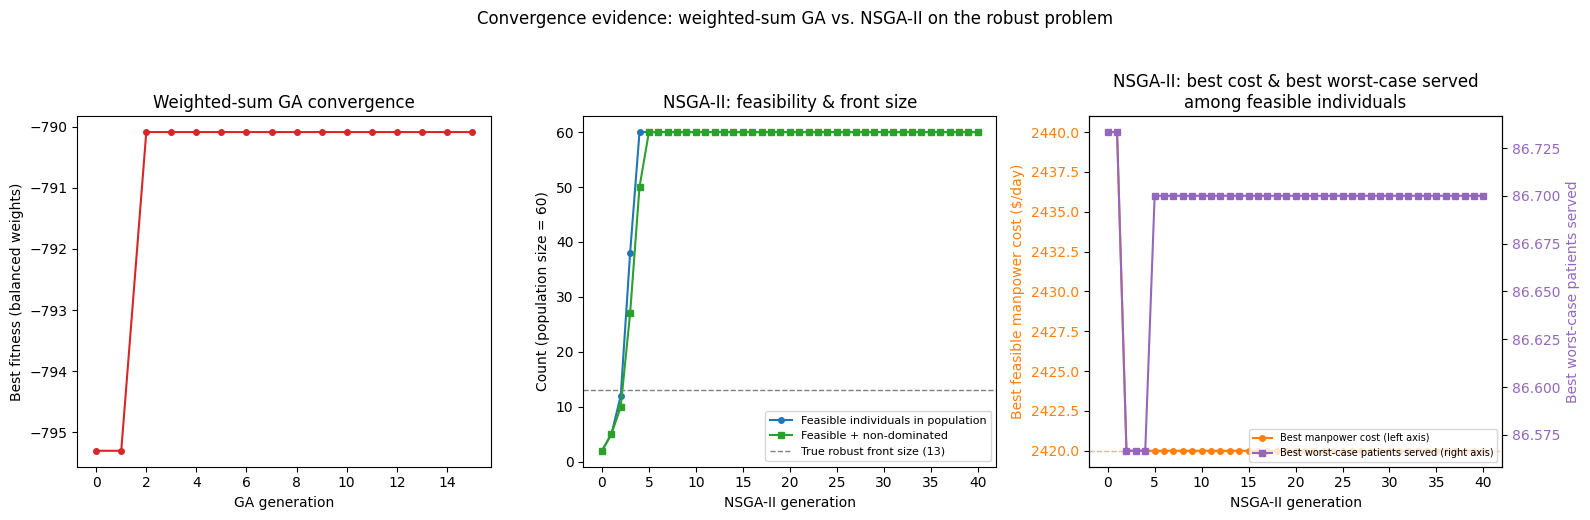

Saved: figures/convergence.png


In [ ]:
FIGURE_DPI = 300
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(range(len(ga_log_result["history"])), ga_log_result["history"], "-o",
             color="tab:red", markersize=4)
axes[0].set_xlabel("GA generation")
axes[0].set_ylabel("Best fitness (balanced weights)")
axes[0].set_title("Weighted-sum GA convergence")

axes[1].plot(nsga2_history_df.index, nsga2_history_df.n_feasible, "-o", color="tab:blue", markersize=4,
             label="Feasible individuals in population")
axes[1].plot(nsga2_history_df.index, nsga2_history_df.n_feasible_nondominated, "-s", color="tab:green",
             markersize=4, label="Feasible + non-dominated")
axes[1].axhline(len(robust_front_df), color="gray", linestyle="--", linewidth=1,
                 label=f"True robust front size ({len(robust_front_df)})")
axes[1].set_xlabel("NSGA-II generation")
axes[1].set_ylabel("Count (population size = 60)")
axes[1].set_title("NSGA-II: feasibility & front size")
axes[1].legend(fontsize=8)

ln1 = axes[2].plot(nsga2_history_df.index, nsga2_history_df.best_manpower_cost, "-o",
                    color="tab:orange", markersize=4, label="Best manpower cost (left axis)")
axes[2].axhline(cheapest_robust["manpower_cost"], color="tab:orange", linestyle="--", linewidth=1, alpha=0.6,
                 label=f"True cheapest robust cost (${cheapest_robust['manpower_cost']:.0f})")
axes[2].set_xlabel("NSGA-II generation")
axes[2].set_ylabel("Best feasible manpower cost ($/day)", color="tab:orange")
axes[2].tick_params(axis="y", labelcolor="tab:orange")

ax2b = axes[2].twinx()
ln2 = ax2b.plot(nsga2_history_df.index, nsga2_history_df.best_served_robust, "-s",
                 color="tab:purple", markersize=4, label="Best worst-case patients served (right axis)")
ax2b.set_ylabel("Best worst-case patients served", color="tab:purple")
ax2b.tick_params(axis="y", labelcolor="tab:purple")

lines = ln1 + ln2
axes[2].legend(lines, [l.get_label() for l in lines], fontsize=7, loc="lower right")
axes[2].set_title("NSGA-II: best cost & best worst-case served\namong feasible individuals")

fig.suptitle("Convergence evidence: weighted-sum GA vs. NSGA-II on the robust problem", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "convergence.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print("Saved:", FIGURES_DIR / "convergence.png")

## Summary

In [ ]:
print(f"Ground truth: nominal front={len(nominal_front_df)}, robust front={len(robust_front_df)}")
print(f"Confidence intervals: {len(stat_df)} configuration-scenario pairs tested, "
      f"{n_borderline} borderline (95% CI crosses the {MIN_SERVICE_LEVEL:.0%} floor)")
print(f"NSGA-II stability ({len(STABILITY_SEEDS_NSGA2)} seeds, n={N_REPLICATIONS_STABILITY}):")
print(nsga2_stability_df.to_string(index=False))
print(f"Weighted-sum GA stability ({len(STABILITY_SEEDS_GA)} seeds, n={N_REPLICATIONS_STABILITY}):")
print(ga_stability_df.to_string(index=False))
print(f"GA convergence (balanced weights, seed=42): best fitness by generation = "
      f"{[round(v,1) for v in ga_log_result['history']]}")
print(f"NSGA-II convergence (seed=42), final generation: {nsga2_history[-1]}")
print()
print("Files written this notebook:")
for f in sorted((TABLES_DIR).glob("*")):
    print(" ", f)
for f in sorted((FIGURES_DIR).glob("*")):
    print(" ", f)

Ground truth: nominal front=17, robust front=13
Confidence intervals: 42 configuration-scenario pairs tested, 9 borderline (95% CI crosses the 90% floor)
NSGA-II stability (5 seeds, n=15):
 seed  solutions_found  match_true_front  true_front_size  includes_cheapest_robust_point
   42               16                11               13                            True
    7               16                11               13                            True
  123               16                11               13                            True
 2024               16                11               13                            True
   99               16                11               13                            True
Weighted-sum GA stability (3 seeds, n=15):
 seed  solutions_found  match_true_front  true_front_size
   42                3                 3               13
    7                3                 3               13
  123                3                 3              